# MEDA Rolling-Origin Hyperparameter Tuning and Selection

In [7]:
from pathlib import Path
import sys, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
OUTPUTS, MODELS = ROOT/'outputs', ROOT/'models'
sns.set_theme(style='whitegrid')

ridge=pd.read_csv(OUTPUTS/'ridge_trials_v2.csv'); xgb=pd.read_csv(OUTPUTS/'xgboost_trials_v2.csv'); display(ridge.sort_values('value')); display(xgb.sort_values('value'))

,number,value,datetime_start,datetime_complete,duration,params_alpha,state
6,6,10.155617,2026-07-29 16:21:51.365199,2026-07-29 16:22:04.085185,0 days 00:00:12.719986,39.025636,COMPLETE
2,2,10.206238,2026-07-29 16:20:02.871832,2026-07-29 16:20:29.490833,0 days 00:00:26.619001,26.601976,COMPLETE
7,7,10.403888,2026-07-29 16:22:04.085274,2026-07-29 16:22:16.629596,0 days 00:00:12.544322,16.175753,COMPLETE
1,1,13.994369,2026-07-29 16:19:41.056193,2026-07-29 16:20:02.850053,0 days 00:00:21.793860,998.722545,COMPLETE
3,3,14.500329,2026-07-29 16:20:29.494639,2026-07-29 16:20:54.633370,0 days 00:00:25.138731,3.664011,COMPLETE
0,0,14.904782,2026-07-29 16:19:10.020431,2026-07-29 16:19:41.053447,0 days 00:00:31.033016,3.534923,COMPLETE
4,4,15.360697,2026-07-29 16:20:54.652193,2026-07-29 16:21:21.823372,0 days 00:00:27.171179,0.008869,COMPLETE
5,5,18.887648,2026-07-29 16:21:21.824220,2026-07-29 16:21:51.338885,0 days 00:00:29.514665,0.034851,COMPLETE


,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_subsample,state
5,5,7.890618,2026-07-29 16:27:43.621497,2026-07-29 16:28:21.475156,0 days 00:00:37.853659,0.749774,0.077611,5,12,350,0.847092,COMPLETE
3,3,8.059119,2026-07-29 16:26:29.922492,2026-07-29 16:27:00.051420,0 days 00:00:30.128928,0.758617,0.034092,3,8,300,0.655171,COMPLETE
0,0,8.274443,2026-07-29 16:22:16.963982,2026-07-29 16:24:19.403521,0 days 00:02:02.439539,0.666095,0.062076,7,8,400,0.683853,COMPLETE
2,2,8.416717,2026-07-29 16:25:55.974146,2026-07-29 16:26:29.921776,0 days 00:00:33.947630,0.690400,0.035364,6,4,250,0.665407,COMPLETE
1,1,8.458563,2026-07-29 16:24:19.414029,2026-07-29 16:25:55.967547,0 days 00:01:36.553518,0.803749,0.024101,6,5,400,0.719308,COMPLETE
4,4,8.722942,2026-07-29 16:27:00.051607,2026-07-29 16:27:43.621358,0 days 00:00:43.569751,0.860765,0.075277,7,5,300,0.717017,COMPLETE


## Search outcome

Ridge used **8** log-scaled regularisation trials; XGBoost used **6** bounded trials over estimator count, depth, learning rate, child weight and row/column subsampling. Each objective averaged three rolling-origin validation errors and excluded the final temporal test. The trial counts were deliberately bounded for the 8 GB CPU-only system.

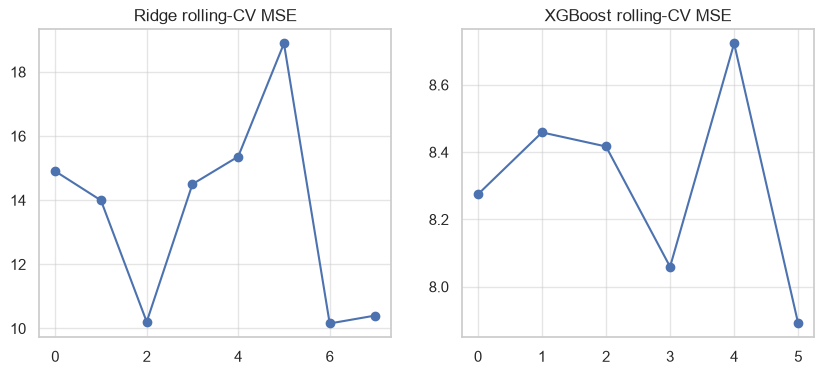

In [8]:
fig,ax=plt.subplots(1,2,figsize=(10,4)); ax[0].plot(ridge.number,ridge.value,marker='o'); ax[0].set_title('Ridge rolling-CV MSE'); ax[1].plot(xgb.number,xgb.value,marker='o'); ax[1].set_title('XGBoost rolling-CV MSE'); plt.show()

## Figure 1 - Tuning histories

**Finding.** Trial-to-trial variation confirms that both regularisation and tree complexity materially affect forward validation.

**Implication.** Best parameters are chosen by mean rolling-origin MSE and then locked before final testing.

**Limitation.** A bounded TPE search does not prove a global optimum; it trades exhaustive coverage for reproducibility and hardware safety.

## Artifact decision

The final bundle exports **physics_residual**, its exact feature order, raw schema, feature ranges, temporal coverage, library versions, seed, test metrics and appropriate-use limitations. The selection rule is independent of Kaggle rank. The old artifact is preserved for traceability rather than overwritten.